# AFTS Strategy 9 + Strategy 25 (Dynamic Optimisation)
## Using pysystemtrade with bundled CSV data

This notebook implements:
1. **Strategy 9** — Multiple trend following (EWMAC at various speeds)
2. **Strategy 25** — Dynamic optimisation (integer position sizing for smaller accounts)

---

## Part 0: Verify Setup

In [1]:
# Verify pysystemtrade is importable
import sys
import warnings
warnings.filterwarnings('ignore')  # suppress noisy warnings during backtest

try:
    from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
    print("pysystemtrade imported successfully")
except ImportError as e:
    print(f"Import error: {e}")
    print("Make sure pysystemtrade is installed: pip install -e /path/to/pysystemtrade")
    print("Or add it to sys.path:")
    print("  sys.path.insert(0, '/path/to/pysystemtrade')")

Configuring sim logging
pysystemtrade imported successfully


In [2]:
# Check available instruments in the bundled CSV data
data = csvFuturesSimData()
instruments = data.get_instrument_list()
print(f"Available instruments ({len(instruments)}):")
print(instruments)

Available instruments (252):
['FTSECHINAH', 'EU-MID', 'EU-DIV30', 'JP-REALESTATE', 'SMI', 'DJSTX-SMALL', 'LUMBER-new', 'EUROSTX200-LARGE', 'CAD5', 'PALLAD', 'HIGHYIELD', 'GBPEUR', 'SP500_micro', 'BOVESPA', 'IRON', 'LEANHOG', 'GAS-LAST', 'US-STAPLES', 'ETHER-micro', 'WHEAT_ICE', 'VNKI', 'SOYBEAN', 'EU-DJ-UTIL', 'FTSEINDO', 'NZD', 'ETHANOL', 'GOLD', 'MSCIASIA', 'BB3M', 'CAD2', 'EU-DJ-TECH', 'JPY_mini', 'EU-TECH', 'MIB', 'SMI-MID', 'GILT', 'BTP', 'EU-TRAVEL', 'MSCIWORLD', 'SWISSLEAD', 'SOYBEAN_mini', 'KRWUSD_mini', 'STEEL', 'HANGTECH', 'NASDAQ_micro', 'ROBUSTA', 'VIX_mini', 'CAD10', 'AEX', 'BBCOMM', 'NASDAQ', 'EU-HOUSE', 'HOUSE-US', 'NIKKEI400', 'RUSSELL', 'GASOILINE_micro', 'EURIBOR-ICE', 'CANOLA', 'EU-HEALTH', 'HEATOIL-ICE', 'MSCIEAFA', 'SUGAR16', 'SILVER', 'EUA', 'COPPER-micro', 'CHEESE', 'CAD_micro', 'EURCHF', 'GAS-PEN', 'MILKWET', 'CAC', 'CHF_micro', 'GASOIL', 'AUD', 'EU-CHEM', 'EU-DJ-OIL', 'BUND', 'EU-FOOD', 'US-MATERIAL', 'US10', 'KR10', 'GASOILINE_ICE', 'US-UTILS', 'EU-RETAIL', 'I

In [4]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

data_check = csvFuturesSimData()
all_instruments = data_check.get_instrument_list()
print(f"All available instruments ({len(all_instruments)}):")
print(all_instruments)

Configuring sim logging
All available instruments (252):
['FTSECHINAH', 'EU-MID', 'EU-DIV30', 'JP-REALESTATE', 'SMI', 'DJSTX-SMALL', 'LUMBER-new', 'EUROSTX200-LARGE', 'CAD5', 'PALLAD', 'HIGHYIELD', 'GBPEUR', 'SP500_micro', 'BOVESPA', 'IRON', 'LEANHOG', 'GAS-LAST', 'US-STAPLES', 'ETHER-micro', 'WHEAT_ICE', 'VNKI', 'SOYBEAN', 'EU-DJ-UTIL', 'FTSEINDO', 'NZD', 'ETHANOL', 'GOLD', 'MSCIASIA', 'BB3M', 'CAD2', 'EU-DJ-TECH', 'JPY_mini', 'EU-TECH', 'MIB', 'SMI-MID', 'GILT', 'BTP', 'EU-TRAVEL', 'MSCIWORLD', 'SWISSLEAD', 'SOYBEAN_mini', 'KRWUSD_mini', 'STEEL', 'HANGTECH', 'NASDAQ_micro', 'ROBUSTA', 'VIX_mini', 'CAD10', 'AEX', 'BBCOMM', 'NASDAQ', 'EU-HOUSE', 'HOUSE-US', 'NIKKEI400', 'RUSSELL', 'GASOILINE_micro', 'EURIBOR-ICE', 'CANOLA', 'EU-HEALTH', 'HEATOIL-ICE', 'MSCIEAFA', 'SUGAR16', 'SILVER', 'EUA', 'COPPER-micro', 'CHEESE', 'CAD_micro', 'EURCHF', 'GAS-PEN', 'MILKWET', 'CAC', 'CHF_micro', 'GASOIL', 'AUD', 'EU-CHEM', 'EU-DJ-OIL', 'BUND', 'EU-FOOD', 'US-MATERIAL', 'US10', 'KR10', 'GASOILINE_ICE',

In [5]:
# Check which instruments have enough data to be usable
import pandas as pd

print(f"{'Instrument':12s} {'Start':>12s} {'End':>12s} {'Days':>8s}")
print("-" * 46)
for inst in sorted(all_instruments):
    try:
        prices = data_check.get_raw_price(inst)
        print(f"{inst:12s} {str(prices.index[0].date()):>12s} {str(prices.index[-1].date()):>12s} {len(prices):>8d}")
    except Exception as e:
        print(f"{inst:12s} ERROR: {e}")

Instrument          Start          End     Days
----------------------------------------------
AEX            2009-08-18   2024-03-28    75040
AEX_mini       2009-07-16   2024-03-28    70861
ALUMINIUM      2019-12-13   2024-03-28     6087
ALUMINIUM_LME   2023-06-01   2024-03-28     2263
AUD            1987-06-16   2024-03-28    52253
AUDJPY         2021-12-14   2024-03-28     1482
AUD_micro      1987-03-16   2024-03-28    52232
BB3M           2022-03-15   2024-03-28      698
BBCOMM         2006-12-12   2024-03-28    15988
BITCOIN        2017-12-22   2024-03-28    26976
BOBL           2008-03-05   2024-03-28   116533
BONO           2016-03-02   2024-03-28    20229
BOVESPA        2012-12-12   2024-03-28     9706
BRE            1995-12-01   2024-03-28    25168
BRENT-LAST     2020-08-27   2024-03-28     5962
BRENT_W        1989-08-11   2024-03-28    67588
BTP            2010-03-04   2024-03-28    88623
BTP3           2011-09-07   2024-03-28    35110
BUND           2006-12-01   2024-03-28  

In [6]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

data_check = csvFuturesSimData()
all_instruments = data_check.get_instrument_list()

# 1. Exclude mini/micro duplicates — these track the same underlying
#    and would create fake diversification
exclude_suffixes = ['_mini', '_micro', '-mini', '-micro']
exclude_keywords = ['_mini', '_micro']

duplicates = set()
for inst in all_instruments:
    inst_lower = inst.lower()
    if any(kw in inst_lower for kw in ['_mini', '_micro', '-mini', '-micro']):
        duplicates.add(inst)

# Also exclude specific known duplicates (same underlying, different exchange/contract)
specific_duplicates = {
    'AEX_mini', 'AUD_micro', 'CAD_micro', 'CHF_micro', 'COPPER-micro', 
    'COPPER-mini', 'CORN_mini', 'CRUDE_W_micro', 'CRUDE_W_mini',
    'DOW_mini', 'ETHER-micro', 'EUR_micro', 'EUR_mini', 'GASOILINE_micro',
    'GAS_US_mini', 'GBP_micro', 'GOLD-mini', 'GOLD_micro', 'HANG_mini',
    'HANGENT_mini', 'IBEX_mini', 'JGB-mini', 'JGB-SGX-mini', 'JPY_mini',
    'KOSPI_mini', 'KRWUSD_mini', 'NASDAQ_micro', 'RUSSELL_mini',
    'SGD_mini', 'SOYBEAN_mini', 'SP500_micro', 'TWD-mini', 'VIX_mini',
    'WHEAT_mini',
    # Same underlying different venue/version
    'BRENT-LAST', 'GAS-LAST', 'ALUMINIUM_LME', 'COPPER_LME', 
    'NICKEL_LME', 'LEAD_LME', 'TIN_LME', 'ZINC_LME',
    'GASOILINE_ICE', 'HEATOIL-ICE', 'EURIBOR-ICE',
    'CNH-onshore', 'COAL-GEORDIE',
}
duplicates.update(specific_duplicates)

# 2. Minimum data threshold — need enough history for meaningful backtest
MIN_DAYS = 5000  # roughly 20 years of trading days, ~8 calendar years

usable = []
too_short = []
for inst in sorted(all_instruments):
    if inst in duplicates:
        continue
    try:
        prices = data_check.get_raw_price(inst)
        if len(prices) >= MIN_DAYS:
            usable.append(inst)
        else:
            too_short.append((inst, len(prices)))
    except:
        pass

print(f"=== Instrument Filtering Results ===")
print(f"Total available:     {len(all_instruments)}")
print(f"Excluded duplicates: {len(duplicates)}")
print(f"Too short (<{MIN_DAYS} days): {len(too_short)}")
print(f"USABLE:              {len(usable)}")
print(f"\n--- Usable instruments ({len(usable)}) ---")
for inst in usable:
    print(f"  {inst}")

print(f"\n--- Too short (excluded) ---")
for inst, days in sorted(too_short, key=lambda x: x[1]):
    print(f"  {inst:20s} {days:>6d} days")

=== Instrument Filtering Results ===
Total available:     252
Excluded duplicates: 47
Too short (<5000 days): 32
USABLE:              173

--- Usable instruments (173) ---
  AEX
  ALUMINIUM
  AUD
  BBCOMM
  BITCOIN
  BOBL
  BONO
  BOVESPA
  BRE
  BRENT_W
  BTP
  BTP3
  BUND
  BUTTER
  BUXL
  CAC
  CAD
  CAD10
  CAD2
  CAD5
  CANOLA
  CH10
  CHEESE
  CHF
  CNH
  COAL
  COCOA
  COCOA_LDN
  COFFEE
  COPPER
  CORN
  COTTON2
  CRUDE_ICE
  CRUDE_W
  CZK
  DAX
  DJSTX-SMALL
  DOW
  DX
  ETHEREUM
  EU-AUTO
  EU-BANKS
  EU-BASIC
  EU-CHEM
  EU-CONSTRUCTION
  EU-DIV30
  EU-DJ-OIL
  EU-DJ-TECH
  EU-DJ-TELECOM
  EU-DJ-UTIL
  EU-FOOD
  EU-HEALTH
  EU-INSURE
  EU-MEDIA
  EU-MID
  EU-OIL
  EU-REALESTATE
  EU-RETAIL
  EU-TECH
  EU-TRAVEL
  EU-UTILS
  EUR
  EURCHF
  EURIBOR
  EURO600
  EUROSTX
  EUROSTX-LARGE
  EUROSTX-SMALL
  EUROSTX200-LARGE
  FANG
  FED
  FEEDCOW
  FTSE100
  FTSE250
  FTSECHINAA
  FTSECHINAH
  FTSEINDO
  FTSETAIWAN
  GAS-PEN
  GASOIL
  GASOILINE
  GAS_US
  GBP
  GBPEUR
  GICS
  GILT

SP500 price data:
  Date range: 1982-09-14 to 2024-03-28
  Data points: 35898
  Last 5 prices:
index
2024-03-28 17:00:00    5309.25
2024-03-28 18:00:00    5316.50
2024-03-28 19:00:00    5305.25
2024-03-28 20:00:00    5303.50
2024-03-28 23:00:00    5304.25
Name: price, dtype: float64


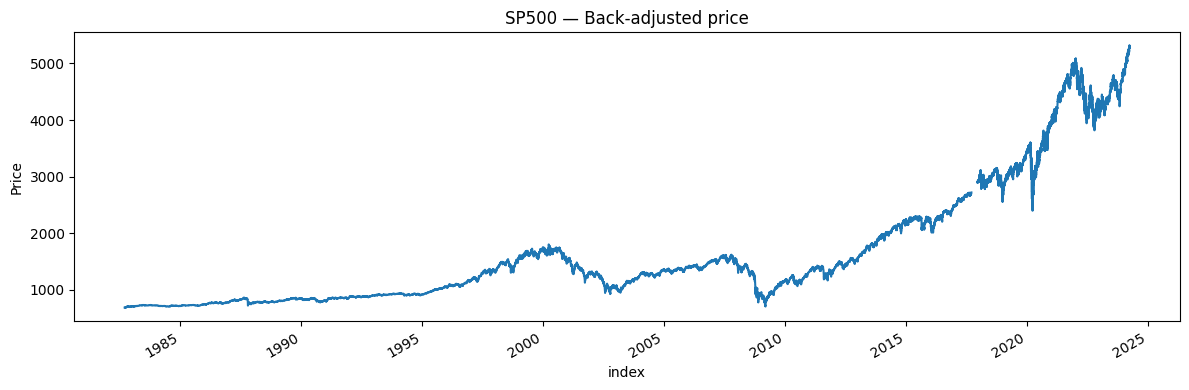

In [3]:
# Quick sanity check — look at one instrument's price data
import matplotlib.pyplot as plt
%matplotlib inline

test_instrument = 'SP500'
prices = data.get_raw_price(test_instrument)
print(f"{test_instrument} price data:")
print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Data points: {len(prices)}")
print(f"  Last 5 prices:")
print(prices.tail())

fig, ax = plt.subplots(figsize=(12, 4))
prices.plot(ax=ax, title=f'{test_instrument} — Back-adjusted price')
ax.set_ylabel('Price')
plt.tight_layout()
plt.show()

---
## Part 1: Strategy 9 — Multiple Trend Following

Strategy 9 uses EWMAC (exponentially weighted moving average crossover) at multiple speeds.
pysystemtrade's `futures_chapter15` system has all of this built in.

**What happens under the hood:**
- EWMAC rules at various fast/slow combos generate raw forecasts
- Forecasts are scaled (avg absolute = 10) and capped (±20)
- Multiple forecasts are combined with weights + diversification multiplier
- Positions are sized using the vol-targeting formula
- Buffering prevents unnecessary trades

In [4]:
# Build Strategy 9 using the chapter 15 pre-baked system
# This uses the default config which includes EWMAC rules, fixed weights, etc.
from systems.provided.futures_chapter15.basesystem import futures_system
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

data = csvFuturesSimData()
system = futures_system(data=data)

print("System stages:")
for stage_name in system.stage_names:
    print(f"  {stage_name}: {type(system.__dict__.get(stage_name, 'N/A')).__name__}")

Private configuration '/Users/vipullade/Documents/systematicTrading/futuresSystemAlgo/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode
System stages:
  accounts: Account
  portfolio: Portfolios
  positionSize: PositionSizing
  rawdata: RawData
  combForecast: ForecastCombine
  forecastScaleCap: ForecastScaleCap
  rules: Rules


In [5]:
# What trading rules are configured?
rules = system.rules.trading_rules()
print(f"Trading rules ({len(rules)}):")
for rule_name, rule in sorted(rules.items()):
    print(f"  {rule_name}")

print(f"\nInstruments in portfolio:")
print(list(system.config.instrument_weights.keys()))

Trading rules (7):
  carry
  ewmac16_64
  ewmac2_8
  ewmac32_128
  ewmac4_16
  ewmac64_256
  ewmac8_32

Instruments in portfolio:
['SOFR', 'US10', 'EUROSTX', 'V2X', 'MXP', 'CORN']


In [6]:
# Look at the config to understand what's set
config = system.config
print("Key config parameters:")
print(f"  notional_trading_capital: {config.notional_trading_capital}")
print(f"  base_currency: {config.base_currency}")
print(f"  percentage_vol_target: {config.percentage_vol_target}")
print(f"  forecast_cap: {config.forecast_cap}")

print(f"\nInstrument weights:")
for inst, weight in sorted(config.instrument_weights.items()):
    print(f"  {inst}: {weight}")

if hasattr(config, 'forecast_weights'):
    print(f"\nForecast weights:")
    for rule, weight in sorted(config.forecast_weights.items()):
        print(f"  {rule}: {weight}")
else:
    print("\nForecast weights: equal (default)")

Key config parameters:
  notional_trading_capital: 250000
  base_currency: USD
  percentage_vol_target: 20.0
  forecast_cap: 20.0

Instrument weights:
  CORN: 0.233
  EUROSTX: 0.2
  MXP: 0.233
  SOFR: 0.117
  US10: 0.117
  V2X: 0.098

Forecast weights:
  carry: 0.5
  ewmac16_64: 0.21
  ewmac32_128: 0.08
  ewmac64_256: 0.21


In [7]:
from systems.provided.futures_chapter15.basesystem import futures_system
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysdata.config.configdata import Config

# Start from the chapter 15 config as a base (has EWMAC rules, forecast weights, etc.)
config = Config("systems.provided.futures_chapter15.futuresconfig.yaml")

# Override with our 173 instruments — equal weights
usable = [  'AEX',
  'ALUMINIUM',
  'AUD',
  'BBCOMM',
  'BITCOIN',
  'BOBL',
  'BONO',
  'BOVESPA',
  'BRE',
  'BRENT_W',
  'BTP',
  'BTP3',
  'BUND',
  'BUTTER',
  'BUXL',
  'CAC',
  'CAD',
  'CAD10',
  'CAD2',
  'CAD5',
  'CANOLA',
  'CH10',
  'CHEESE',
  'CHF',
  'CNH',
  'COAL',
  'COCOA',
  'COCOA_LDN',
  'COFFEE',
  'COPPER',
  'CORN',
  'COTTON2',
  'CRUDE_ICE',
  'CRUDE_W',
  'CZK',
  'DAX',
  'DJSTX-SMALL',
  'DOW',
  'DX',
  'ETHEREUM',
  'EU-AUTO',
  'EU-BANKS',
  'EU-BASIC',
  'EU-CHEM',
  'EU-CONSTRUCTION',
  'EU-DIV30',
  'EU-DJ-OIL',
  'EU-DJ-TECH',
  'EU-DJ-TELECOM',
  'EU-DJ-UTIL',
  'EU-FOOD',
  'EU-HEALTH',
  'EU-INSURE',
  'EU-MEDIA',
  'EU-MID',
  'EU-OIL',
  'EU-REALESTATE',
  'EU-RETAIL',
  'EU-TECH',
  'EU-TRAVEL',
  'EU-UTILS',
  'EUR',
  'EURCHF',
  'EURIBOR',
  'EURO600',
  'EUROSTX',
  'EUROSTX-LARGE',
  'EUROSTX-SMALL',
  'EUROSTX200-LARGE',
  'FANG',
  'FED',
  'FEEDCOW',
  'FTSE100',
  'FTSE250',
  'FTSECHINAA',
  'FTSECHINAH',
  'FTSEINDO',
  'FTSETAIWAN',
  'GAS-PEN',
  'GASOIL',
  'GASOILINE',
  'GAS_US',
  'GBP',
  'GBPEUR',
  'GICS',
  'GILT',
  'GOLD',
  'HANG',
  'HANGTECH',
  'HEATOIL',
  'HIGHYIELD',
  'IBEX',
  'INR',
  'IRON',
  'JGB',
  'JP-REALESTATE',
  'JPY',
  'KOSDAQ',
  'KOSPI',
  'KR10',
  'KR3',
  'LEANHOG',
  'LIVECOW',
  'MILK',
  'MILKDRY',
  'MILKWET',
  'MILLWHEAT',
  'MSCIASIA',
  'MSCIEAFA',
  'MSCISING',
  'MUMMY',
  'MXP',
  'NASDAQ',
  'NIKKEI',
  'NIKKEI400',
  'NOK',
  'NZD',
  'OAT',
  'OATIES',
  'OJ',
  'OMX',
  'PALLAD',
  'PLAT',
  'PLN',
  'R1000',
  'REDWHEAT',
  'RICE',
  'ROBUSTA',
  'RUR',
  'RUSSELL',
  'SEK',
  'SGX',
  'SHATZ',
  'SILVER',
  'SMI',
  'SMI-MID',
  'SOFR',
  'SONIA3',
  'SOYBEAN',
  'SOYMEAL',
  'SOYOIL',
  'SP400',
  'SP500',
  'STEEL',
  'SUGAR11',
  'SUGAR16',
  'SUGAR_WHITE',
  'TOPIX',
  'US-DISCRETE',
  'US-ENERGY',
  'US-FINANCE',
  'US-HEALTH',
  'US-INDUSTRY',
  'US-MATERIAL',
  'US-PROPERTY',
  'US-REALESTATE',
  'US-STAPLES',
  'US-TECH',
  'US-UTILS',
  'US10',
  'US10U',
  'US2',
  'US20',
  'US3',
  'US30',
  'US5',
  'V2X',
  'VIX',
  'WHEAT',
  'WHEAT_ICE',
  'WHEY',
  'YENEUR',
  'ZAR',
]

equal_weight = round(1.0 / len(usable), 6)
config.instrument_weights = {inst: equal_weight for inst in usable}

# IDM for a large diversified portfolio — 2.5 is standard for 100+ instruments
config.instrument_div_multiplier = 2.5

config.notional_trading_capital = 500000  # your actual capital
config.base_currency = 'USD'

data = csvFuturesSimData()
system = futures_system(data=data, config=config)

print(f"Instruments: {len(usable)}")
print(f"Weight per instrument: {equal_weight:.6f}")
print(f"IDM: {config.instrument_div_multiplier}")

Private configuration '/Users/vipullade/Documents/systematicTrading/futuresSystemAlgo/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode
Instruments: 173
Weight per instrument: 0.005780
IDM: 2.5


### 1.1 Inspect the forecast pipeline for a single instrument

In [7]:
# Pick an instrument and trace the entire pipeline
instrument = 'SP500'  # change this to any instrument in the portfolio

# Step 1: Raw forecasts from each EWMAC rule
print(f"=== Forecasts for {instrument} ===")
rule_names = list(rules.keys())
for rule_name in sorted(rule_names):
    try:
        raw = system.rules.get_raw_forecast(instrument, rule_name)
        print(f"  {rule_name}: last value = {raw.iloc[-1]:.2f}, mean abs = {raw.abs().mean():.2f}")
    except Exception as e:
        print(f"  {rule_name}: error — {e}")

=== Forecasts for SP500 ===
2026-04-25 18:05:33 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-04-25 18:05:33 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-04-25 18:05:33 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-04-25 18:05:33 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for carry
2026-04-25 18:05:33 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily volatility for SP500
2026-04-25 18:05:33 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'SP500'} Calculating daily prices for SP500
  carry: last value = -0.40, mean abs = 0.18
2026-04-25 18:05:33 DEBUG base_system {'stage': 'rules', 'instrument_code': 'SP500'} Calculating raw forecast SP500 for ewmac16_64
2026-04-25 18:05:33 DEBUG base_system {'stage': 'rawdat

In [8]:
# Step 2: Scaled & capped forecasts
print(f"\n=== Scaled & Capped Forecasts for {instrument} ===")
for rule_name in sorted(rule_names):
    try:
        scaled = system.forecastScaleCap.get_capped_forecast(instrument, rule_name)
        print(f"  {rule_name}: last = {scaled.iloc[-1]:.2f}, mean abs = {scaled.abs().mean():.2f}")
    except Exception as e:
        print(f"  {rule_name}: error — {e}")


=== Scaled & Capped Forecasts for SP500 ===
2026-04-25 18:10:24 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 carry
  carry: last = -11.90, mean abs = 5.52
2026-04-25 18:10:24 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 ewmac16_64
  ewmac16_64: last = 20.00, mean abs = 8.18
2026-04-25 18:10:24 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 ewmac2_8
  ewmac2_8: last = 7.33, mean abs = 7.95
2026-04-25 18:10:24 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 ewmac32_128
  ewmac32_128: last = 20.00, mean abs = 8.77
2026-04-25 18:10:24 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'SP500'} Calculating capped forecast for SP500 ewmac4_16
  ewmac4_16: last = 10.80, mean abs = 7.83
2026-04-25 18:10:24 DEBU

In [9]:
# Step 3: Combined forecast
combined = system.combForecast.get_combined_forecast(instrument)
print(f"\n=== Combined Forecast for {instrument} ===")
print(f"  Last 5 values:")
print(combined.tail())
print(f"  Mean absolute: {combined.abs().mean():.2f}")
print(f"  Current forecast: {combined.iloc[-1]:.2f}")
print(f"  Interpretation: {'LONG' if combined.iloc[-1] > 0 else 'SHORT' if combined.iloc[-1] < 0 else 'FLAT'}")
print(f"  Conviction: {abs(combined.iloc[-1])/20*100:.0f}% of max")

2026-04-25 18:10:37 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating combined forecast for SP500
2026-04-25 18:10:37 DEBUG base_system {'stage': 'combForecast', 'instrument_code': 'SP500'} Calculating forecast weights for SP500
2026-04-25 18:10:37 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'CORN'} Calculating capped forecast for CORN carry
2026-04-25 18:10:37 DEBUG base_system {'stage': 'rules', 'instrument_code': 'CORN'} Calculating raw forecast CORN for carry
2026-04-25 18:10:37 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'CORN'} Calculating daily volatility for CORN
2026-04-25 18:10:37 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'CORN'} Calculating daily prices for CORN
2026-04-25 18:10:38 DEBUG base_system {'stage': 'forecastScaleCap', 'instrument_code': 'EUROSTX'} Calculating capped forecast for EUROSTX carry
2026-04-25 18:10:38 DEBUG base_system {'stage': 'rules', 'instrument_code': 'EUROSTX'} 

In [16]:
# Step 4: Position sizing — what position does the system want?
# get_notional_position only works for instruments in instrument_weights
# For any instrument, use get_subsystem_position instead (pre-portfolio-weighting)

if instrument in system.config.instrument_weights:
    position = system.portfolio.get_notional_position(instrument)
    label = "Notional position (portfolio-weighted)"
else:
    position = system.positionSize.get_subsystem_position(instrument)
    label = "Subsystem position (pre-portfolio-weight — not in instrument_weights)"

print(f"\n=== Position for {instrument} ===")
print(f"  Type: {label}")
print(f"  Last 5 positions (contracts):")
print(position.tail())
print(f"\n  Current target position: {position.iloc[-1]:.2f} contracts")
print(f"  Rounded: {round(position.iloc[-1])} contracts")


=== Position for SP500 ===
  Type: Subsystem position (pre-portfolio-weight — not in instrument_weights)
  Last 5 positions (contracts):
index
2024-03-22    0.999262
2024-03-25    1.047047
2024-03-26    1.078389
2024-03-27    1.080264
2024-03-28    1.094708
Freq: B, dtype: float64

  Current target position: 1.09 contracts
  Rounded: 1 contracts


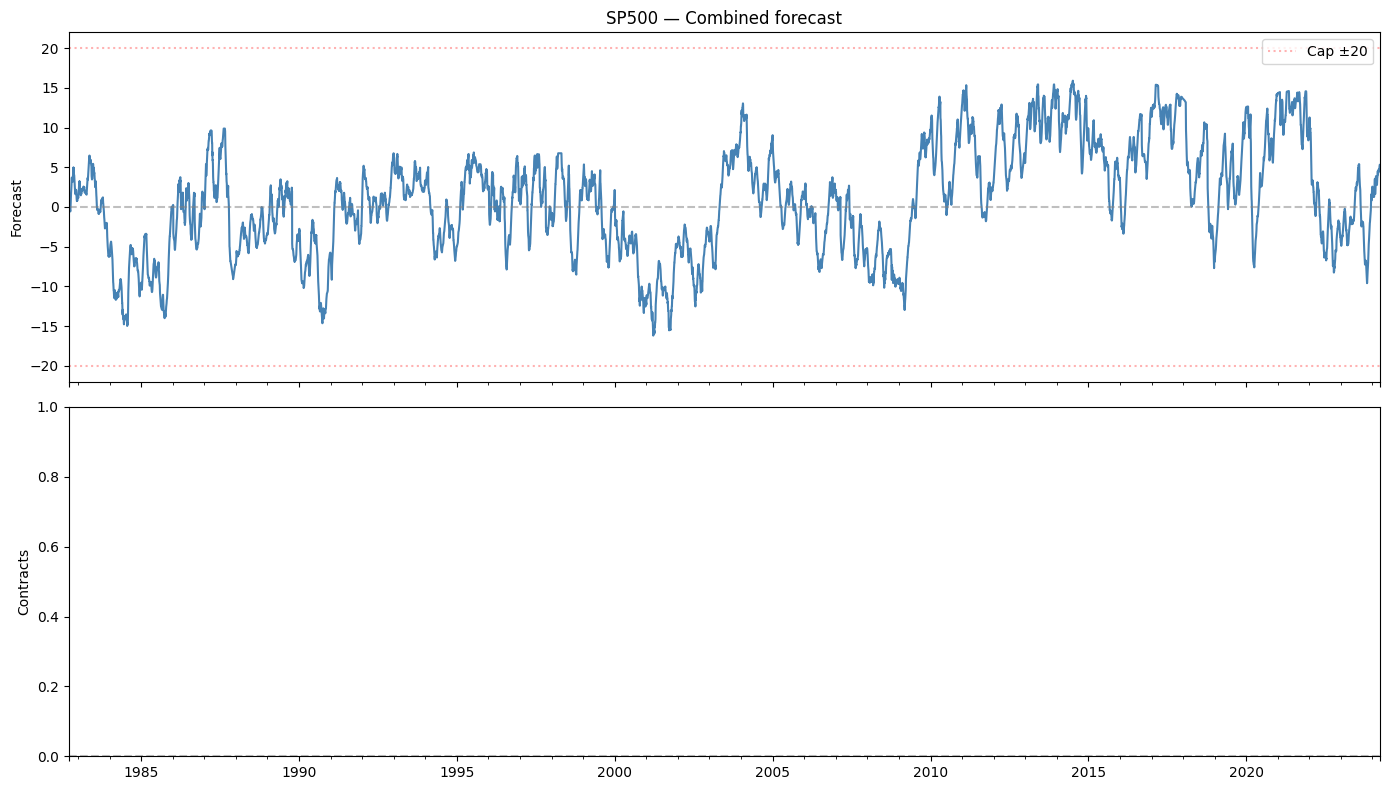

In [17]:
# Plot the combined forecast over time
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Forecast
combined.plot(ax=axes[0], title=f'{instrument} — Combined forecast', color='steelblue')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=20, color='red', linestyle=':', alpha=0.3, label='Cap ±20')
axes[0].axhline(y=-20, color='red', linestyle=':', alpha=0.3)
axes[0].set_ylabel('Forecast')
axes[0].legend()

# Position
if instrument in system.config.instrument_weights:
    position = system.portfolio.get_notional_position(instrument)
    label = "Notional position (portfolio-weighted)"
else:
    position = system.positionSize.get_subsystem_position(instrument)
    label = "Subsystem position (pre-portfolio-weight — not in instrument_weights)"
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Contracts')

plt.tight_layout()
plt.show()

### 1.2 Full Portfolio Backtest — Strategy 9

In [12]:
# Run the full portfolio backtest (this may take a minute)
print("Running portfolio backtest...")
portfolio_account = system.accounts.portfolio()

print("\n=== Strategy 9 — Portfolio Performance ===")
print(portfolio_account.percent.stats())

Running portfolio backtest...
2026-04-25 18:14:15 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-04-25 18:14:15 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'SP500'} Getting vol target
2026-04-25 18:14:15 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-04-25 18:14:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating notional position for CORN
2026-04-25 18:14:15 INFO base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Using fixed diversification multiplier 1.890000
2026-04-25 18:14:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} No risk overlay in config: won't apply risk scaling
2026-04-25 18:14:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating buffers for CORN
2026-04-25 18:14:15 DEBUG base_system {'stage': 'portfolio', 'instrument_code': 'CORN'} Calculating forecast method buff

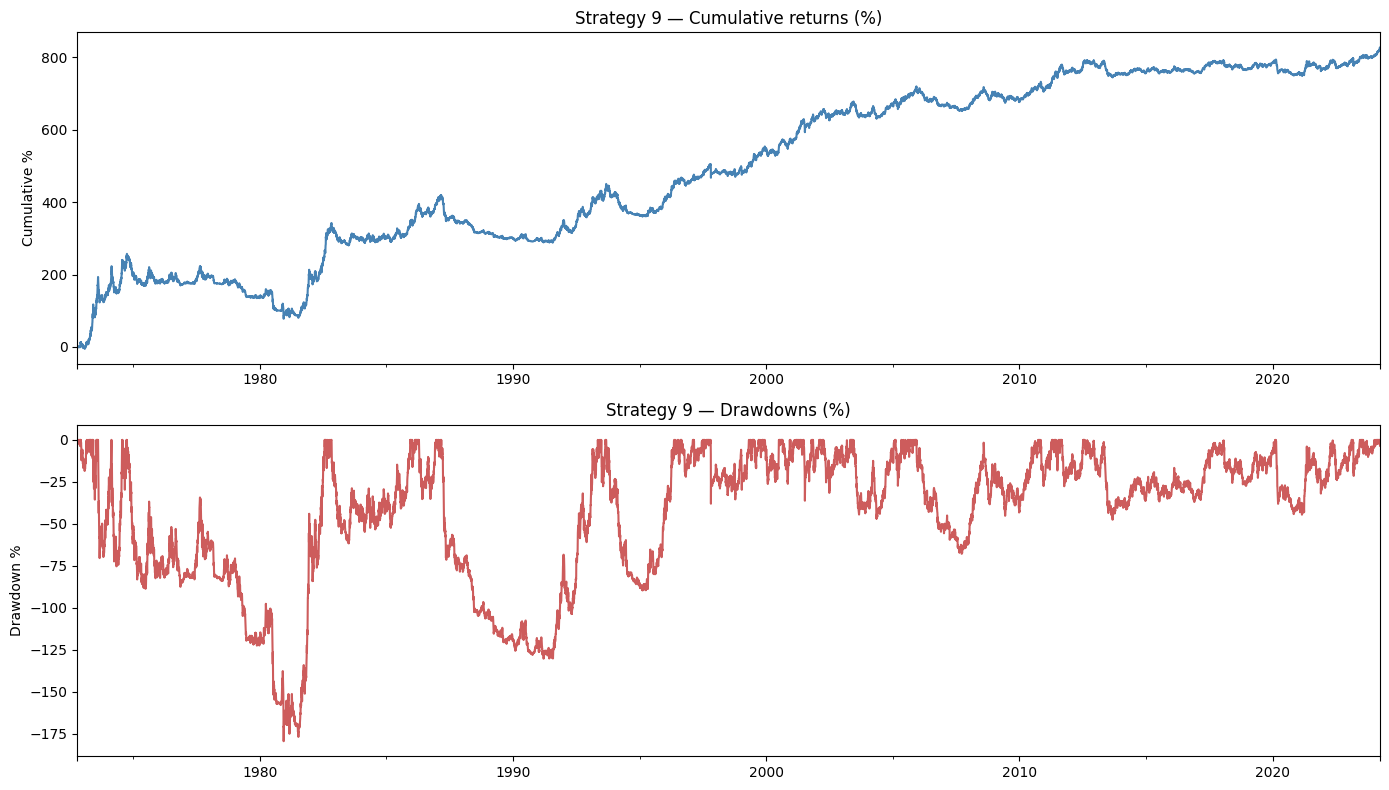

In [13]:
# Equity curve
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full equity curve
portfolio_account.percent.curve().plot(ax=axes[0], 
    title='Strategy 9 — Cumulative returns (%)', color='steelblue')
axes[0].set_ylabel('Cumulative %')

# Drawdowns
portfolio_account.percent.drawdown().plot(ax=axes[1],
    title='Strategy 9 — Drawdowns (%)', color='indianred')
axes[1].set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()

In [14]:
# Per-instrument breakdown
print("\n=== Per-instrument Sharpe ratios ===")
instrument_list = list(system.config.instrument_weights.keys())
for inst in sorted(instrument_list):
    try:
        inst_account = system.accounts.pandl_for_subsystem(inst)
        sr = inst_account.sharpe()
        print(f"  {inst:12s}: SR = {sr:.3f}")
    except Exception as e:
        print(f"  {inst:12s}: error — {e}")


=== Per-instrument Sharpe ratios ===
2026-04-25 18:14:29 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for subsystem for instrument CORN
2026-04-25 18:14:29 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'CORN'} Calculating buffers for CORN
2026-04-25 18:14:29 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'CORN'} Calculating forecast method buffers for CORN
2026-04-25 18:14:29 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating buffered subsystem positions
2026-04-25 18:14:29 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'CORN'} Calculating daily prices for CORN
  CORN        : SR = 0.092
2026-04-25 18:14:29 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'EUROSTX'} Calculating pandl for subsystem for instrument EUROSTX
2026-04-25 18:14:29 DEBUG base_system {'stage': 'positionSize', 'instrument_code': 'EUROSTX'} Calculating buffers for EUROSTX
2026-04-25 18:14:29 D

In [15]:
# Current positions across all instruments — this is what you'd trade TODAY
print("\n=== Current Notional Positions (last row) ===")
print(f"{'Instrument':12s} {'Position':>10s} {'Rounded':>10s}")
print("-" * 34)
for inst in sorted(instrument_list):
    try:
        pos = system.portfolio.get_notional_position(inst)
        last_pos = pos.iloc[-1]
        print(f"{inst:12s} {last_pos:10.2f} {round(last_pos):10.0f}")
    except Exception as e:
        print(f"{inst:12s} {'error':>10s}")


=== Current Notional Positions (last row) ===
Instrument     Position    Rounded
----------------------------------
CORN              -6.39         -6
EUROSTX            5.52          6
MXP               18.39         18
SOFR              -0.55         -1
US10              -1.65         -2
V2X              -33.87        -34


---
## Part 2: Strategy 25 — Dynamic Optimisation

Dynamic optimisation solves the problem: "I can't afford integer positions in ALL instruments."

It takes the ideal continuous positions from Strategy 9 and finds the best **integer** 
subset of positions that minimizes tracking error vs the ideal portfolio, subject to:
- Positions must be integers (including zero = don't trade this instrument)
- Trading costs are accounted for (don't churn)
- Capital constraints are respected

This uses additional pysystemtrade stages:
- `Risk` — calculates risk metrics
- `portfolioWeightsStage` — dynamic instrument weight calculation
- `optimisedPositions` — the actual integer position optimizer
- `accountForOptimisedStage` — P&L accounting for the optimised system

In [22]:
with open('systems/provided/rob_system/run_system.py', 'r') as f:
    print(f.read())

"""
import matplotlib
matplotlib.use("TkAgg")
"""
from syscore.constants import arg_not_supplied

# from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
from sysdata.sim.db_futures_sim_data import dbFuturesSimData
from sysdata.config.configdata import Config

from systems.forecasting import Rules
from systems.basesystem import System
from systems.forecast_combine import ForecastCombine
from systems.provided.attenuate_vol.vol_attenuation_forecast_scale_cap import (
    volAttenForecastScaleCap,
)
from systems.provided.rob_system.rawdata import myFuturesRawData
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.provided.dynamic_small_system_optimise.optimised_positions_stage import (
    optimisedPositions,
)
from systems.risk import Risk
from systems.provided.dynamic_small_system_optimise.accounts_stage import (
    accountForOptimisedStage,
)


def futures_system(
    sim_data=arg_not_supplied,
    config_filename="systems.

In [23]:
# Build the Dynamic Optimisation system
from sysdata.config.configdata import Config
from systems.forecasting import Rules
from systems.basesystem import System
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

# Dynamic optimisation specific stages — corrected for your version
from systems.provided.dynamic_small_system_optimise.optimised_positions_stage import optimisedPositions
from systems.provided.dynamic_small_system_optimise.accounts_stage import accountForOptimisedStage
from systems.risk import Risk

print("All dynamic optimisation imports successful")

All dynamic optimisation imports successful


In [26]:
# Use the chapter 15 config as the base — this has the EWMAC rules and weights
data_do = csvFuturesSimData()
config_do = Config("systems.provided.futures_chapter15.futuresconfig.yaml")

# IMPORTANT: Set your actual trading capital here
# Dynamic optimisation results depend heavily on this number
# because it determines which instruments you can afford integer positions in
config_do.notional_trading_capital = 500000  # USD — adjust to your actual capital
config_do.base_currency = 'USD'

print(f"Capital: ${config_do.notional_trading_capital:,.0f}")
print(f"Currency: {config_do.base_currency}")

Capital: $500,000
Currency: USD


In [28]:
data_do = csvFuturesSimData()
config_do = Config("systems.provided.futures_chapter15.futuresconfig.yaml")

config_do.notional_trading_capital = 500000  # adjust to your actual capital
config_do.base_currency = 'USD'

system_do = System(
    [
        Risk(),
        accountForOptimisedStage(),
        optimisedPositions(),
        Portfolios(),
        PositionSizing(),
        RawData(),
        ForecastCombine(),
        ForecastScaleCap(),
        Rules(),
    ],
    data_do,
    config_do,
)

print("Dynamic Optimisation system built successfully")

Private configuration '/Users/vipullade/Documents/systematicTrading/futuresSystemAlgo/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode
Dynamic Optimisation system built successfully


In [8]:
from systems.forecasting import Rules
from systems.basesystem import System
from systems.forecast_combine import ForecastCombine
from systems.forecast_scale_cap import ForecastScaleCap
from systems.rawdata import RawData
from systems.positionsizing import PositionSizing
from systems.portfolio import Portfolios
from systems.provided.dynamic_small_system_optimise.optimised_positions_stage import optimisedPositions
from systems.provided.dynamic_small_system_optimise.accounts_stage import accountForOptimisedStage
from systems.risk import Risk

# Use the SAME config from Part 1 — same 173 instruments, same weights
data_do = csvFuturesSimData()

system_do = System(
    [
        Risk(),
        accountForOptimisedStage(),
        optimisedPositions(),
        Portfolios(),
        PositionSizing(),
        RawData(),
        ForecastCombine(),
        ForecastScaleCap(),
        Rules(),
    ],
    data_do,
    config,  # reuse the same config object
)

print(f"DO system built with {len(usable)} instruments")

Private configuration '/Users/vipullade/Documents/systematicTrading/futuresSystemAlgo/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode
DO system built with 173 instruments


In [29]:
# Run the dynamic optimisation backtest
# WARNING: This takes significantly longer than the basic backtest (5-15 minutes)
# because it solves an optimisation problem for every trading day

print("Running dynamic optimisation backtest...")
print("(This will take several minutes — the optimiser runs for every day in the backtest)")

do_portfolio = system_do.accounts.optimised_portfolio()

print("\n=== Strategy 25 — Dynamic Optimisation Performance ===")
print(do_portfolio.percent.stats())

Running dynamic optimisation backtest...
(This will take several minutes — the optimiser runs for every day in the backtest)
2026-04-25 18:31:11 DEBUG base_system Following instruments are 'duplicate_markets' ['Another_thing', 'bad_thing'] 
2026-04-25 18:31:11 DEBUG base_system Following instruments are marked as 'ignore_instruments': not included: ['EXAMPLE']
2026-04-25 18:31:11 DEBUG base_system Following instruments removed entirely from sim: ['Another_thing', 'EXAMPLE', 'bad_thing']
2026-04-25 18:31:11 INFO base_system {'stage': 'accounts'} Calculating pandl for portfolio
2026-04-25 18:31:11 DEBUG base_system {'stage': 'positionSize'} Getting vol target
2026-04-25 18:31:11 DEBUG base_system {'stage': 'accounts', 'instrument_code': 'CORN'} Calculating pandl for instrument for CORN
2026-04-25 18:31:11 DEBUG base_system {'stage': 'optimisedPositions'} Optimising positions for small capital: may take a while!
2026-04-25 18:31:11 INFO base_system {'stage': 'portfolio'} Calculating instr

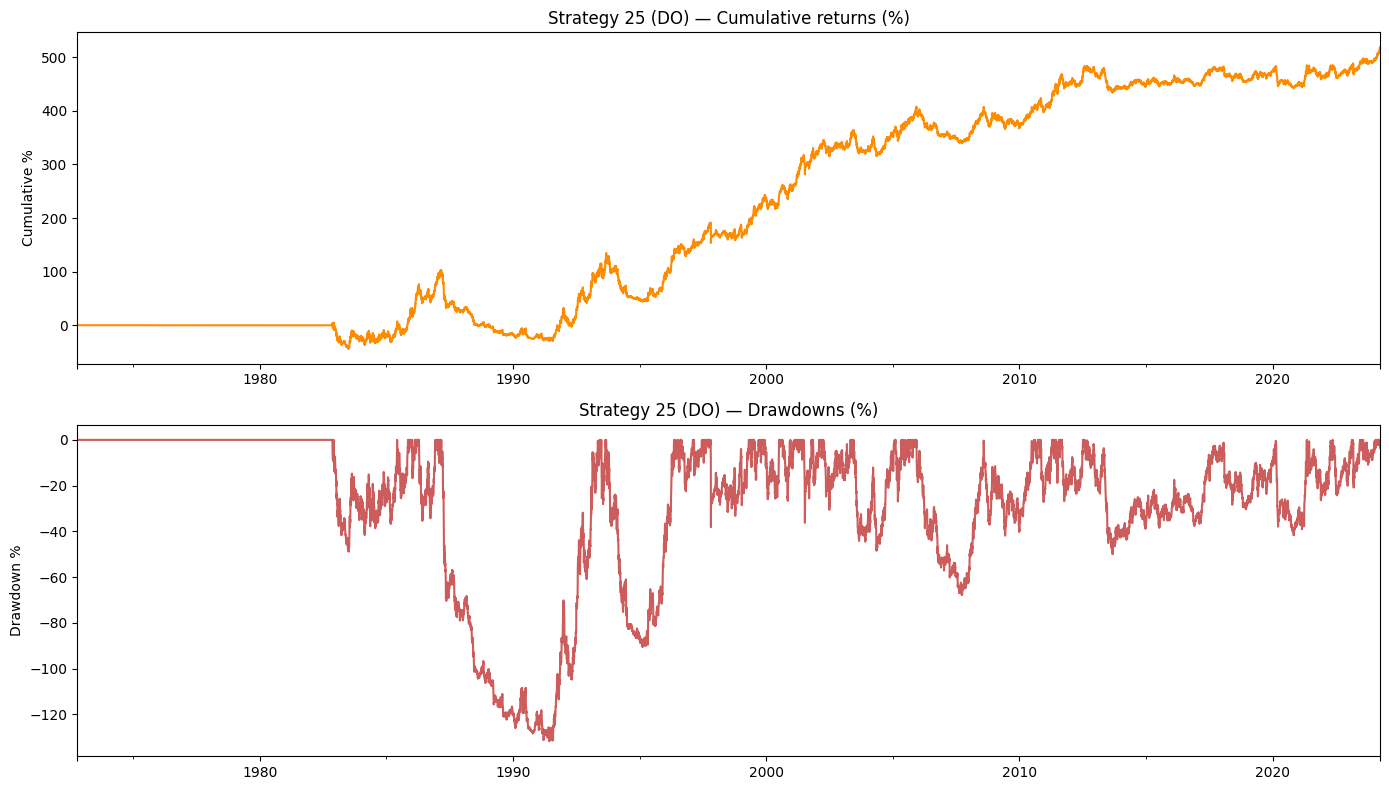

In [30]:
# Equity curve for Dynamic Optimisation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

do_portfolio.percent.curve().plot(ax=axes[0], 
    title='Strategy 25 (DO) — Cumulative returns (%)', color='darkorange')
axes[0].set_ylabel('Cumulative %')

do_portfolio.percent.drawdown().plot(ax=axes[1],
    title='Strategy 25 (DO) — Drawdowns (%)', color='indianred')
axes[1].set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()

### 2.1 Compare Strategy 9 vs Strategy 25

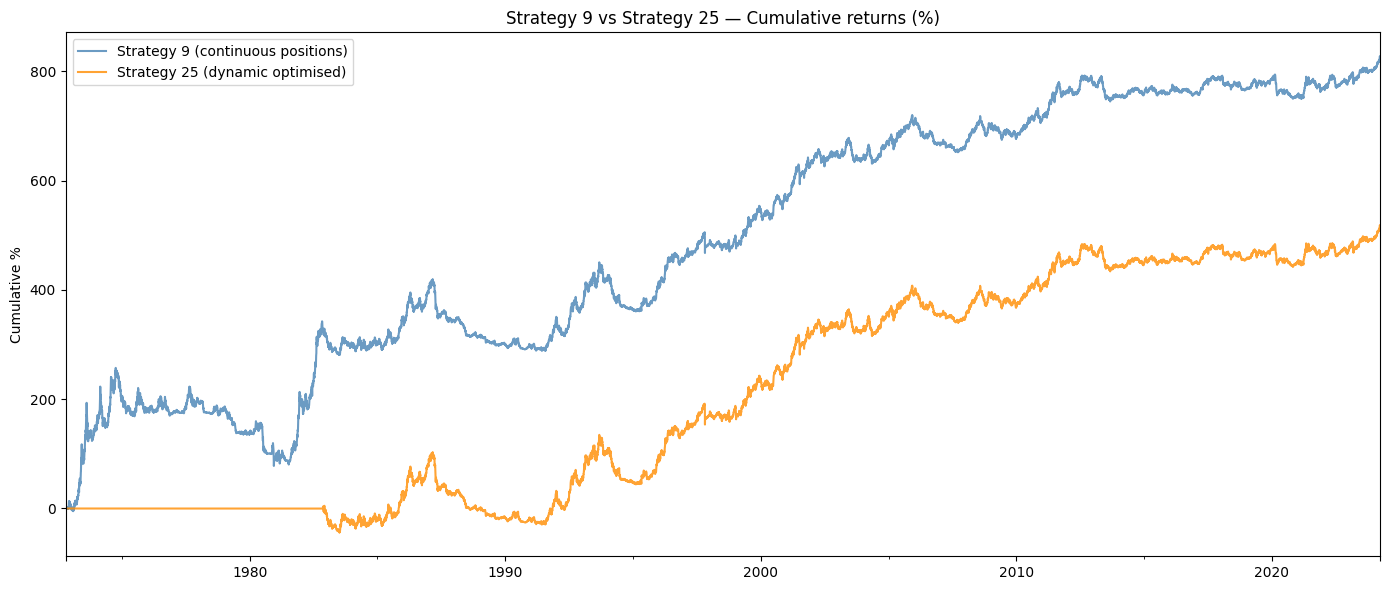


The gap between the two curves shows the 'cost' of having limited capital
and needing integer positions. A larger capital reduces this gap.


In [31]:
# Side by side comparison
import pandas as pd

# Get both equity curves on a common date range
s9_curve = portfolio_account.percent.curve()
s25_curve = do_portfolio.percent.curve()

fig, ax = plt.subplots(figsize=(14, 6))
s9_curve.plot(ax=ax, label='Strategy 9 (continuous positions)', color='steelblue', alpha=0.8)
s25_curve.plot(ax=ax, label='Strategy 25 (dynamic optimised)', color='darkorange', alpha=0.8)
ax.set_title('Strategy 9 vs Strategy 25 — Cumulative returns (%)')
ax.set_ylabel('Cumulative %')
ax.legend()
plt.tight_layout()
plt.show()

print("\nThe gap between the two curves shows the 'cost' of having limited capital")
print("and needing integer positions. A larger capital reduces this gap.")

---
## Part 3: Inspect Optimised Positions

This is the most important output — what the system says you should hold RIGHT NOW.

In [34]:
# Get the optimised (integer) positions
print("=== Optimised Positions (latest) ===")

try:
    # Try the method that works in your version
    opt_positions = system_do.optimisedPosition.get_optimised_position_df()
    print(type(opt_positions))
    print(opt_positions.tail())
except Exception as e:
    print(f"get_optimised_position_df failed: {e}")
    
    # Try alternative approaches
    try:
        instrument_list = system_do.get_instrument_list()
        print(f"\nInstrument list: {instrument_list}")
        print(f"\n{'Instrument':12s} {'Ideal':>10s} {'Optimised':>10s}")
        print("-" * 34)
        for inst in sorted(instrument_list):
            try:
                ideal = system_do.portfolio.get_notional_position(inst).iloc[-1]
                opt = system_do.optimisedPosition.get_optimised_position_for_instrument(inst).iloc[-1]
                print(f"{inst:12s} {ideal:10.2f} {opt:10.0f}")
            except Exception as e2:
                print(f"{inst:12s} error: {e2}")
    except Exception as e3:
        print(f"Alternative approach also failed: {e3}")
        
        # Last resort: inspect what methods are available
        print("\nAvailable methods on optimisedPosition:")
        print([m for m in dir(system_do.optimisedPosition) if not m.startswith('_')])

=== Optimised Positions (latest) ===
get_optimised_position_df failed: 'System' object has no attribute 'optimisedPosition'

Instrument list: ['CORN', 'EUROSTX', 'MXP', 'SOFR', 'US10', 'V2X']

Instrument        Ideal  Optimised
----------------------------------
CORN         error: 'System' object has no attribute 'optimisedPosition'
EUROSTX      error: 'System' object has no attribute 'optimisedPosition'
MXP          error: 'System' object has no attribute 'optimisedPosition'
SOFR         error: 'System' object has no attribute 'optimisedPosition'
US10         error: 'System' object has no attribute 'optimisedPosition'
V2X          error: 'System' object has no attribute 'optimisedPosition'


---
## Part 4: Sensitivity Tests

Before going live, test how results change with different capital levels.

In [ ]:
# Test with different capital levels
# WARNING: Each run takes several minutes
# Uncomment and run if you want to test sensitivity

# capital_levels = [100_000, 250_000, 500_000, 1_000_000]
# results = {}
# 
# for capital in capital_levels:
#     print(f"\nRunning backtest with ${capital:,.0f}...")
#     data_test = csvFuturesSimData()
#     config_test = Config("systems.provided.futures_chapter15.futuresconfig.yaml")
#     config_test.notional_trading_capital = capital
#     config_test.base_currency = 'USD'
#     
#     system_test = System(
#         [
#             Risk(), accountForOptimisedStage(), optimisedPositions(),
#             portfolioWeightsStage(), Portfolios(), PositionSizing(),
#             RawData(), ForecastCombine(), ForecastScaleCap(), Rules(),
#         ],
#         data_test, config_test,
#     )
#     
#     port = system_test.accounts.optimised_portfolio()
#     sr = port.sharpe()
#     results[capital] = sr
#     print(f"  Sharpe ratio: {sr:.3f}")
# 
# print("\n=== Capital Sensitivity ===")
# for cap, sr in results.items():
#     print(f"  ${cap:>10,.0f} → SR = {sr:.3f}")

---
## Part 5: Validation Checklist

Before going live, verify these with your trading partner:

In [33]:
# Validation checklist
print("=" * 60)
print("VALIDATION CHECKLIST — Review with your trading partner")
print("=" * 60)

s9_sr = portfolio_account.sharpe()
print(f"\n1. Strategy 9 Sharpe ratio: {s9_sr:.3f}")
print(f"   Expected range from book: ~0.5-1.0 (depends on period)")
print(f"   {'OK' if 0.3 < s9_sr < 1.5 else 'INVESTIGATE — outside expected range'}")

print(f"\n2. Number of instruments: {len(instrument_list)}")
print(f"   All have data? Check for missing/short series")

print(f"\n3. Capital: ${config_do.notional_trading_capital:,.0f}")
print(f"   Does this match your actual trading capital?")

print(f"\n4. Risk target: {config_do.percentage_vol_target}%")
print(f"   Is your partner comfortable with this vol level?")

print(f"\n5. Forecast weights: {'Fixed' if not getattr(config_do, 'use_forecast_weight_estimates', False) else 'Estimated'}")
print(f"   For live trading, fixed weights are recommended")

print(f"\n6. Maximum drawdown in backtest:")
max_dd = portfolio_account.percent.drawdown().min()
print(f"   {max_dd:.1f}%")
print(f"   Can your partner tolerate a drawdown of this magnitude?")

print(f"\n" + "=" * 60)
print("Share these results with your trading partner for validation.")
print("He should confirm the numbers roughly match the book's results.")
print("=" * 60)

VALIDATION CHECKLIST — Review with your trading partner

1. Strategy 9 Sharpe ratio: 0.478
   Expected range from book: ~0.5-1.0 (depends on period)
   OK

2. Number of instruments: 6
   All have data? Check for missing/short series

3. Capital: $500,000
   Does this match your actual trading capital?

4. Risk target: 20.0%
   Is your partner comfortable with this vol level?

5. Forecast weights: Fixed
   For live trading, fixed weights are recommended

6. Maximum drawdown in backtest:
   -179.4%
   Can your partner tolerate a drawdown of this magnitude?

Share these results with your trading partner for validation.
He should confirm the numbers roughly match the book's results.


---
## Next Steps for Live Trading

Once your partner validates these backtest results:

1. **Set up IB connection** — Configure `private_config.yaml` with your IB credentials
2. **Seed data from IB** — Run the data migration scripts to switch from CSV to live data
3. **Export fixed parameters** — Use `yaml_config_with_estimated_parameters` to freeze all fitted values
4. **Paper trade first** — Run the production system in paper mode for 2-4 weeks
5. **Go live** — Switch to real capital once you trust the system

See `docs/production.md` in the pysystemtrade repo for the full production setup guide.

NameError: name 'csvFuturesSimData' is not defined